## Option Data Download

In [ ]:
# from data_loader.fetch_option_data import fetch_data_by_month
# fetch_data_by_month("MU", "2016-01-01", "2026-03-15")

## Bcaktesting the Wheel Strategy

In [6]:
from backtest.backtest import run_wheel_backtest
from backtest.report import WheelPerformanceReport

symbol = "SPY"

result = run_wheel_backtest(
    symbol=symbol,
    start_date="2016-02-01",
    end_date="2026-03-15",
    target_delta=0.2,
    stop_loss_multiple=1.5,
    put_exp_days=12,
    call_exp_days=0,
    initial_cash=5000,
    leverage=10,
)

report = WheelPerformanceReport(result)

In [7]:
report.summary_table()

,Value
Metric,
Symbol,SPY
Start Date,2016-02-01
End Date,2026-03-13
Initial Cash,"$5,000.00"
Ending Equity,"$23,193.66"
Net Profit,"$18,193.66"
Cash Interest Earned,"$3,039.41"
Total Return,363.87%
CAGR,16.39%


In [8]:
report.trade_breakdown_table()

,legs,total_premium,avg_premium,avg_roi,avg_iv,avg_abs_delta,avg_moneyness,avg_days_held
type,,,,,,,,
put,382,"$64,012.50",$167.57,0.12%,19.82%,0.20,-2.98%,8.32


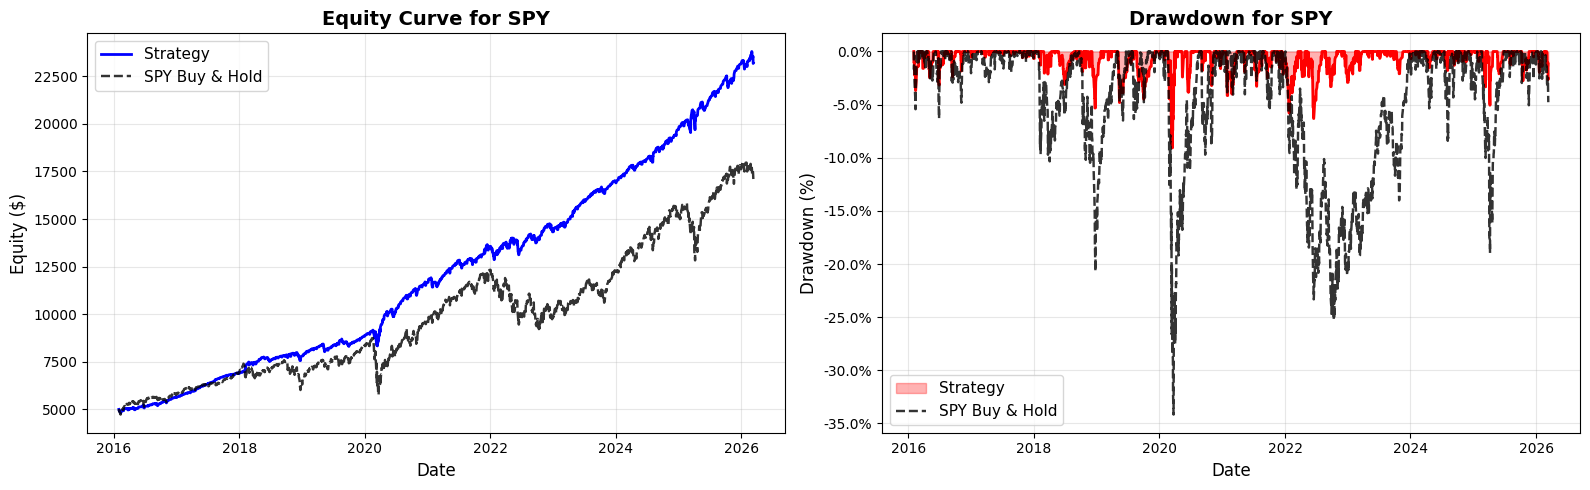

In [9]:
_ = report.plot_equity_and_drawdown()

In [10]:
from IPython.display import HTML, display

def display_long_df(df, max_height=400, max_width='100%'):
    html = (
        f"<div style='max-height:{max_height}px; overflow:auto; width:{max_width}; padding:5px;'>"
        f"{df.to_html(escape=False, index=False)}"
        f"</div>"
    )
    display(HTML(html))

display_long_df(result.trades)

date,side,type,strike,expiration,premium_per_share,premium,delta,leverage_ratio,moneyness,iv,outcome,days_held,ROI%,cash_flow,nav,exec_spot,spot,buyback_price_per_share,stop_trigger_price_per_share,stop_open_price_per_share,liquidation_cost
2016-02-01,short,put,186.5,2016-02-19,1.080,107.999990,-0.205785,3.730000,-3.672331,0.212055,cut_loss,1,-0.289544,-53.999995,4946.058585,193.610,190.340,1.6200,2.25,1.55,NaN
2016-02-03,short,put,184.0,2016-02-19,1.090,109.000000,-0.203721,3.720092,-3.821023,0.232557,cut_loss,2,-0.296196,-54.500000,4891.714240,191.310,188.150,1.6350,2.08,1.09,NaN
2016-02-08,short,put,176.5,2016-02-26,1.285,128.500000,-0.194357,3.608103,-5.030939,0.279949,cut_loss,3,-0.427762,-75.500000,4816.417749,185.850,183.090,2.0400,2.50,2.04,NaN
2016-02-12,short,put,179.0,2016-02-26,1.140,114.000000,-0.206171,3.716417,-3.969957,0.261892,expired,14,0.636872,114.000000,4930.938814,186.400,194.900,NaN,NaN,NaN,NaN
2016-02-29,short,put,185.0,2016-03-18,1.215,121.500000,-0.204496,3.751779,-4.466822,0.238883,expired,18,0.656757,121.500000,5053.243606,193.650,204.310,NaN,NaN,NaN,NaN
2016-03-21,short,put,199.5,2016-04-08,0.725,72.500000,-0.199201,3.947918,-2.568861,0.140980,cut_loss,3,-0.403509,-80.500000,4972.952051,204.760,203.310,1.5300,1.53,1.53,NaN
2016-03-28,short,put,197.5,2016-04-15,0.815,81.500000,-0.200648,3.971445,-2.833809,0.157963,expired,18,0.412658,81.500000,5055.036057,203.260,207.960,NaN,NaN,NaN,NaN
2016-04-18,short,put,204.0,2016-05-06,0.755,75.500000,-0.205631,4.035550,-2.448355,0.138467,cut_loss,11,-0.185049,-37.750000,5017.681804,209.120,206.510,1.1325,1.38,0.79,NaN
2016-05-02,short,put,202.0,2016-05-20,0.815,81.500000,-0.197991,4.025734,-2.842576,0.157100,cut_loss,1,-0.201733,-40.750000,4977.005157,207.910,206.150,1.2225,1.50,1.17,NaN
2016-05-04,short,put,199.0,2016-05-20,0.805,80.500000,-0.192317,3.998363,-3.021442,0.172892,expired,16,0.404523,80.500000,5058.081267,205.200,205.570,NaN,NaN,NaN,NaN


## Grid Search for Hyperparameter Optimization

In [ ]:
import pandas as pd
from backtest.grid_search import run_grid_search

grid_results_spy = run_grid_search(
    symbol=symbol,
    start_date="2016-01-01",
    end_date="2026-03-15",
    initial_cash=8_000,
    leverage=10,
    max_workers=5,
)

In [ ]:
# grid_results = pd.read_csv("data/grid_search/grid_results_spy.csv")
filtered_results = grid_results_spy[grid_results_spy["cagr"] > 0.1]
display_long_df(filtered_results[["case", "cagr", "sharpe", "max_drawdown"]].sort_values(by=["sharpe", "cagr"], ascending=False))

In [ ]:
grid_results_qqq = run_grid_search(
    symbol="QQQ",
    start_date="2016-01-01",
    end_date="2026-03-15",
    initial_cash=5_000,
    leverage=10,
    max_workers=5,
)

In [ ]:
# grid_results_qqq = pd.read_csv("data/grid_search/grid_results_qqq.csv")
filtered_results = grid_results_qqq[grid_results_qqq["cagr"] > 0.1]
display_long_df(filtered_results[["case", "cagr", "sharpe", "max_drawdown"]].sort_values(by=["sharpe", "cagr"], ascending=False))

In [ ]:
from pathlib import Path

data_dir = Path("data/grid_search")
data_dir.mkdir(parents=True, exist_ok=True)

grid_results_spy.to_csv(data_dir / "grid_results_spy.csv", index=False)
grid_results_qqq.to_csv(data_dir / "grid_results_qqq.csv", index=False)